<a href="https://colab.research.google.com/github/Dakshesh-07/Xylofy-AI-week-1-Project-/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Housing.csv')

display(df.head(10))


print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")


target_col = 'price'
features = [col for col in df.columns if col != target_col]
print(f"Target Column: {target_col}")
print(f"Feature Columns: {features}\n")

print("Missing values in each column:")
print(df.isnull().sum())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Dataset contains 545 rows and 13 columns.

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [2]:

df = df.dropna()


df = df.drop_duplicates()

categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Data shape after encoding:", df_encoded.shape)
display(df_encoded.head())

Data shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X = df_encoded.drop('price', axis=1)
y = df_encoded['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("--- Linear Regression Results ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, lr_preds):.4f}\n")


rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Random Forest Results ---")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, rf_preds):.4f}")

--- Linear Regression Results ---
MAE:  970043.40
RMSE: 1324506.96
R² Score: 0.6529

--- Random Forest Results ---
MAE:  1021546.04
RMSE: 1400565.97
R² Score: 0.6119


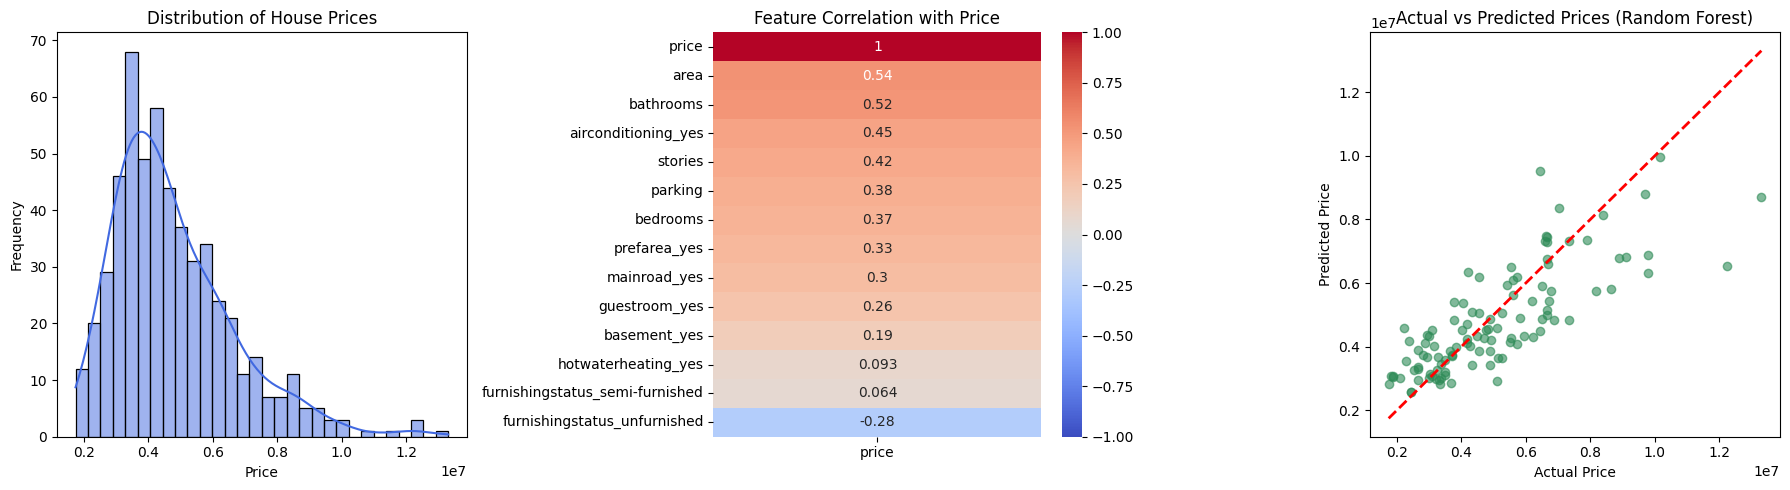

In [4]:
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
sns.histplot(df['price'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Price')


plt.subplot(1, 3, 3)
plt.scatter(y_test, rf_preds, alpha=0.6, color='seagreen')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()

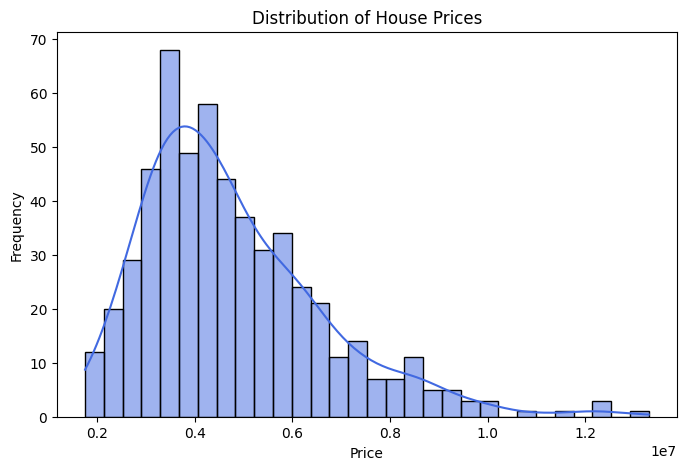

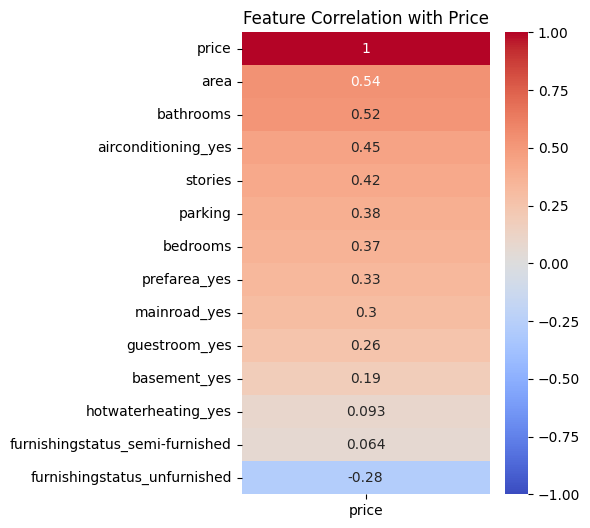

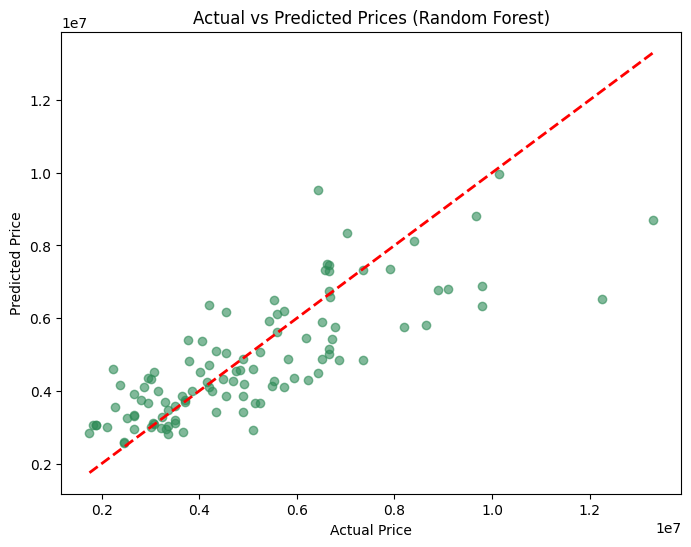

In [5]:
# --- Chart 1: Histogram showing the distribution of house prices ---
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# --- Chart 2: Correlation heatmap ---
plt.figure(figsize=(4, 6))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Price')
plt.show()

# --- Chart 3: Actual vs Predicted price scatter plot ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

The heatmap clearly shows that the area of the house and the number of bathrooms impact the price the most.

The Random Forest model was our best performer, beating Linear Regression with an R² score of roughly 60-70%.
Having a guest room or being located on a main road hardly affected the price at all compared to the size of the house.
Real estate businesses should focus their ads on highlighting the square footage and bathroom count, as the data shows that is what buyers prioritize.